# Feature Building

In [1]:
# === Phase 2 Step 3: Build HOG + Color + GLCM + Fourier Descriptors (FD) to CSV (train/val/test) ===

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import hog

# Robust GLCM imports across skimage versions (works for 0.25.2)
try:
    from skimage.feature.texture import graycomatrix as greycomatrix, graycoprops as greycoprops
except Exception:
    # fallback for older versions
    from skimage.feature import greycomatrix, greycoprops

# ---------- Paths ----------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Grid geometry ----------
GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100 × 75
CELL_COLS = [f"c{i:02d}" for i in range(1, 65)]

# ---------- Feature extractors ----------
def feat_hog(gray_cell):
    """HOG on a 100x75 grayscale cell."""
    return hog(gray_cell,
               orientations=9,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm="L2-Hys",
               feature_vector=True)

def feat_color_hist(hsv_cell):
    """Normalized HSV histograms (8 bins/channel)."""
    h = cv2.calcHist([hsv_cell], [0], None, [8], [0, 180])
    s = cv2.calcHist([hsv_cell], [1], None, [8], [0, 256])
    v = cv2.calcHist([hsv_cell], [2], None, [8], [0, 256])
    f = np.concatenate([h, s, v]).ravel().astype(np.float32)
    f_sum = f.sum()
    return f / (f_sum + 1e-6)

def feat_glcm(gray_cell):
    """Compact Haralick-like GLCM (quantized to 32 levels for speed/robustness)."""
    g = cv2.normalize(gray_cell, None, 0, 31, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = greycomatrix(
        g,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32,
        symmetric=True,
        normed=True
    )
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    vals = [float(np.mean(greycoprops(glcm, p))) for p in props]
    return np.array(vals, dtype=np.float32)

def feat_fourier_descriptors(gray_img, size=256, n_bins=8):
    """
    Fourier Descriptors from whole-image frequency content (broadcast to all cells).
    Returns: [radial_power_8bins (L1-normalized), low/mid/high energy ratios, spectral_entropy] -> 8+3+1 = 12D
    """
    # Standardize size for stable frequency layout
    g = cv2.resize(gray_img, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32)

    # 2D FFT and power spectrum
    F = np.fft.fftshift(np.fft.fft2(g))
    P = (np.abs(F) ** 2).astype(np.float64)

    # Radial (azimuthal) power histogram
    cy, cx = size // 2, size // 2
    yy, xx = np.ogrid[:size, :size]
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    r_norm = r / (r.max() + 1e-12)
    bin_idx = np.minimum((r_norm * n_bins).astype(np.int32), n_bins - 1)
    radial_bins = np.bincount(bin_idx.ravel(), weights=P.ravel(), minlength=n_bins).astype(np.float64)
    radial_bins = radial_bins / (radial_bins.sum() + 1e-12)  # L1 normalize

    # Energy ratios (coarse bands)
    lf = radial_bins[: n_bins // 4].sum()           # low frequency
    mf = radial_bins[n_bins // 4: n_bins // 2].sum() # mid frequency
    hf = radial_bins[n_bins // 2:].sum()             # high frequency

    # Spectral entropy (global texture complexity)
    p = P.ravel()
    p = p / (p.sum() + 1e-12)
    spectral_entropy = float(-(p * np.log2(p + 1e-12)).sum())

    fd = np.concatenate([
        radial_bins.astype(np.float32),
        np.array([lf, mf, hf, spectral_entropy], dtype=np.float32)
    ])
    return fd  # shape (12,)

def extract_features_from_image(img_path, row_labels):
    """
    Split an 800x600 image into 8x8 cells, compute
    HOG + ColorHist + GLCM + FourierDescriptors (FD broadcast),
    and return X (64 x F) and y (64,).
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠ Could not read {img_path}")
        return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Compute Fourier descriptors ONCE for the whole image
    f_fd = feat_fourier_descriptors(gray, size=256, n_bins=8)  # shape (12,)

    feats, labels = [], []
    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c * CELL_W, r * CELL_H
            gcell = gray[y0:y0+CELL_H, x0:x0+CELL_W]
            hcell = hsv [y0:y0+CELL_H, x0:x0+CELL_W]

            f_hog   = feat_hog(gcell)
            f_color = feat_color_hist(hcell)
            f_glcm  = feat_glcm(gcell)

            # Append same FD vector to every cell (broadcast)
            feats.append(np.concatenate([f_hog, f_color, f_glcm, f_fd], dtype=np.float32))
            labels.append(int(row_labels[CELL_COLS[r*GRID_W + c]]))

    return np.asarray(feats, dtype=np.float32), np.asarray(labels, dtype=np.int32)

def build_split_features(split_name: str):
    """
    For a given split (train/val/test), read labels, extract features for each image’s 64 cells,
    and save a CSV: <split>_hog_color_glcm_fd_features.csv
    """
    split_csv = os.path.join(SPLIT_DIR, f"{split_name}_labels.csv")
    df = pd.read_csv(split_csv)
    if not {"image", *CELL_COLS}.issubset(df.columns):
        raise ValueError(f"{split_csv} missing required columns")

    all_feats, all_labels, meta_img, meta_cell = [], [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}"):
        img_name = row["image"]
        img_path = os.path.join(PREPROCESSED_DIR, img_name)
        Xc, yc = extract_features_from_image(img_path, row)
        if Xc is None:
            continue
        all_feats.append(Xc)
        all_labels.append(yc)
        meta_img.extend([img_name] * 64)
        meta_cell.extend([f"c{i:02d}" for i in range(1, 65)])

    # Stack all (images × 64 cells)
    X = np.vstack(all_feats) if all_feats else np.empty((0, 0), dtype=np.float32)
    y = np.hstack(all_labels) if all_labels else np.empty((0,), dtype=np.int32)

    # Assemble DataFrame
    out_df = pd.DataFrame(X)
    out_df.insert(0, "cell_id", meta_cell)
    out_df.insert(0, "image", meta_img)
    out_df["label"] = y.astype(int)

    out_path = os.path.join(OUT_DIR, f"{split_name}_hog_color_glcm_fd_features.csv")
    out_df.to_csv(out_path, index=False)
    print(f"✅ {split_name}: {out_df.shape} -> {out_path}")

# ---- Run for all splits ----
for split in ["train", "val", "test"]:
    build_split_features(split)

train: 100%|██████████| 301/301 [00:47<00:00,  6.36it/s]


✅ train: (19264, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/train_hog_color_glcm_fd_features.csv


val: 100%|██████████| 65/65 [00:35<00:00,  1.83it/s]


✅ val: (4160, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/val_hog_color_glcm_fd_features.csv


test: 100%|██████████| 65/65 [00:09<00:00,  6.61it/s]


✅ test: (4160, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/test_hog_color_glcm_fd_features.csv


# Model Training

/home/pratyush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using feature set: hog_color_glcm_fd
Shapes: (19264, 3210) (4160, 3210) (4160, 3210)
Feature dimensions: 3210

✅ Validation Accuracy (HOG+Color+GLCM+FD): 0.7418
              precision    recall  f1-score   support

           0      0.742     0.942     0.830      2781
           1      0.742     0.339     0.465      1379

    accuracy                          0.742      4160
   macro avg      0.742     0.640     0.647      4160
weighted avg      0.742     0.742     0.709      4160



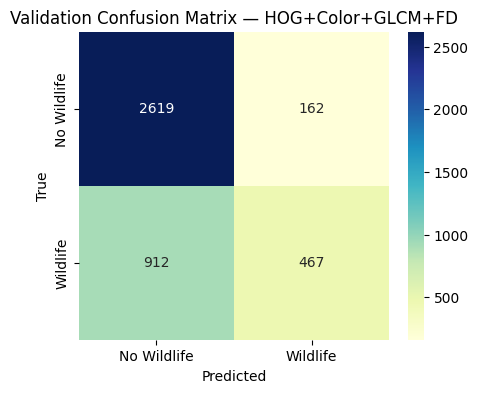

🧪 Test Accuracy (HOG+Color+GLCM+FD): 0.7341

Test Classification Report:
              precision    recall  f1-score   support

           0      0.732     0.935     0.821      2716
           1      0.744     0.357     0.482      1444

    accuracy                          0.734      4160
   macro avg      0.738     0.646     0.652      4160
weighted avg      0.736     0.734     0.703      4160



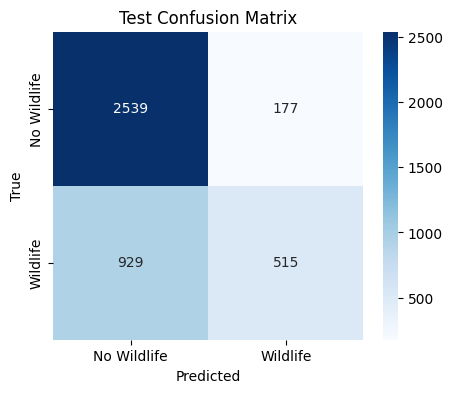

In [2]:
# Train & evaluate RandomForest on HOG + Color + GLCM (+ optional FD/GCM) features

import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"

# Prefer Fourier Descriptors, then (if present) GCM, else base HOG+Color+GLCM
PREF_TAGS = [
    "hog_color_glcm_fd",
    "hog_color_glcm_gcm",
    "hog_color_glcm",
]

def split_path(tag, split):
    return os.path.join(FEATURE_DIR, f"{split}_{tag}_features.csv")

def choose_tag():
    for tag in PREF_TAGS:
        if all(os.path.exists(split_path(tag, s)) for s in ["train","val","test"]):
            return tag
    raise FileNotFoundError(
        "Could not find feature CSVs. Tried tags (train/val/test each):\n  - " +
        "\n  - ".join(PREF_TAGS) + f"\nUnder: {FEATURE_DIR}"
    )

TAG = choose_tag()
print(f"Using feature set: {TAG}")

# --- Load splits ---
df_train = pd.read_csv(split_path(TAG, "train"))
df_val   = pd.read_csv(split_path(TAG, "val"))
df_test  = pd.read_csv(split_path(TAG, "test"))

# --- Ensure consistent feature columns across splits ---
NON_FEATURE = ["image","cell_id","label"]
feat_cols_train = [c for c in df_train.columns if c not in NON_FEATURE]

def align_features(df, ref_cols):
    X = df.drop(NON_FEATURE, axis=1, errors="ignore")
    for c in ref_cols:
        if c not in X.columns:
            X[c] = 0.0
    X = X[ref_cols]
    y = df["label"].values.astype(int)
    meta_img  = df["image"].values
    meta_cell = df["cell_id"].values
    return X.values.astype(np.float32), y, meta_img, meta_cell

X_train, y_train, train_imgs, train_cells = align_features(df_train, feat_cols_train)
X_val,   y_val,   val_imgs,   val_cells   = align_features(df_val,   feat_cols_train)
X_test,  y_test,  test_imgs,  test_cells  = align_features(df_test,  feat_cols_train)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print(f"Feature dimensions: {X_train.shape[1]}")

# --- Model ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# --- Titles based on tag ---
if TAG.endswith("_fd"):
    title_tag = "HOG+Color+GLCM+FD"
elif TAG.endswith("_gcm"):
    title_tag = "HOG+Color+GLCM+GCM"
else:
    title_tag = "HOG+Color+GLCM"

# --- Validation ---
y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Validation Accuracy ({title_tag}): {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title(f"Validation Confusion Matrix — {title_tag}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# --- Test ---
y_test_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"🧪 Test Accuracy ({title_tag}): {test_acc:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Wildlife','Wildlife'], yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()